# SpaceAmb — Prototype Demo

Architectural-semantic research prototype.  Full pipeline:

1. Load atoms, programs, ambiances, scenes
2. Generate embeddings (disk-cached)
3. Score atoms, descriptors, and scenes against all space × ambiance queries
4. Explore: change settings in **Section 0b** to point at any query or scene
5. Evaluate: Hit@1 / Hit@5 ground-truth metrics for scene retrieval
6. Export and visualise

> **Methodological note:** Similarity scores reflect *semantic affinity* in
> embedding space — a research instrument, not perceptual ground truth.

## 0. Setup

In [30]:
import sys
from pathlib import Path

ROOT = Path('.').resolve().parent
src_path = ROOT / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
matplotlib.rcParams['figure.dpi'] = 120
%matplotlib inline

## 0b. Settings  <-- **edit here to explore different queries & scenes**

Change `EXPLORE_SPACE` and `EXPLORE_AMBIANCE` to drill into any combination.
`EXAMPLE_QUERIES` drives the comparison charts and exports throughout the notebook.

Valid values are any `text` entries in `data/raw/programs.json` / `data/raw/ambiances.json`.

In [31]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  PRIMARY EXPLORATION TARGET
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Space (program) — must match a text value in data/raw/programs.json
EXPLORE_SPACE    = 'living room'
# Ambiance — must match a text value in data/raw/ambiances.json
EXPLORE_AMBIANCE = 'relaxing'

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  COMPARISON QUERIES (used in charts, exports, heatmap)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXAMPLE_QUERIES = [
    'relaxing living room',
    'somber conference room',
    'vibrant gym',
    'spooky gallery',
]

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  ATOM TO TRACK ACROSS ALL QUERIES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CROSS_QUERY_ATOM = 'sofa'

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  SCENE TO DEEP-DIVE  (must match an id in data/raw/scenes.json)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXPLORE_SCENE_ID = 'scene_relaxing_living_room_01'

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  DISPLAY DEPTH
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TOP_K        = 20   # atoms / descriptors per query
TOP_K_SCENES = 5    # scenes per query

# Derived — do not edit
EXPLORE_QUERY = f'{EXPLORE_AMBIANCE} {EXPLORE_SPACE}'
print(f'Explore query  : {EXPLORE_QUERY!r}')
print(f'Example queries: {EXAMPLE_QUERIES}')

Explore query  : 'relaxing living room'
Example queries: ['relaxing living room', 'somber conference room', 'vibrant gym', 'spooky gallery']


## 1. Load Config and Datasets

In [32]:
import yaml
from semantic_architecture.atoms import load_atoms, atoms_summary
from semantic_architecture.queries import load_programs, load_ambiances
from semantic_architecture.scenes import load_scenes, scenes_summary, validate_scenes

CONFIG_PATH = ROOT / 'config' / 'config.yaml'
with open(CONFIG_PATH) as fh:
    cfg = yaml.safe_load(fh)

atoms     = load_atoms(ROOT / cfg['data']['atoms_path'])
programs  = load_programs(ROOT / cfg['data']['programs_path'])
ambiances = load_ambiances(ROOT / cfg['data']['ambiances_path'])
scenes    = load_scenes(ROOT / cfg['data']['scenes_path'])

print(atoms_summary(atoms))
print(f"\nPrograms  ({len(programs)}): {[p['text'] for p in programs]}")
print(f"Ambiances ({len(ambiances)}): {[a['text'] for a in ambiances]}")
print()
print(scenes_summary(scenes))

# Validate scenes
valid_spaces = [p['text'] for p in programs]
valid_ambs   = [a['text'] for a in ambiances]
for w in validate_scenes(scenes, valid_spaces, valid_ambs):
    print(f'WARNING: {w}')

Atom summary:
  architecture: 38
  furniture: 16
  fixture: 8
  decoration: 10
  technology: 6
  material: 31
  color: 23
  quality: 35
  lighting: 17
  spatial: 18
  relation: 16
  behavioral: 14
  TOTAL: 232

Programs  (20): ['living room', 'bedroom', 'library', 'laboratory', 'hospital room', 'cafeteria', 'conference room', 'dance hall', 'waiting room', 'gym', 'workshop', 'gallery', 'nursery', 'office', 'chapel', 'spa', 'cinema', 'classroom', 'atrium', 'restaurant']
Ambiances (20): ['relaxing', 'inviting', 'fun', 'somber', 'spooky', 'formal', 'lively', 'intimate', 'sterile', 'restorative', 'playful', 'focused', 'melancholic', 'vibrant', 'sacred', 'raw', 'opulent', 'serene', 'dramatic', 'nostalgic']

Scenes loaded : 18

By space:
  bedroom               : 2
  cafeteria             : 3
  conference room       : 1
  dance hall            : 1
  gallery               : 2
  gym                   : 1
  hospital room         : 1
  laboratory            : 1
  library               : 1
  livin

## 2. Generate Embeddings (Cached)

In [33]:
from semantic_architecture.embeddings import EmbeddingModel
from semantic_architecture.queries import generate_all_queries

emb_cfg = cfg['embedding']
model = EmbeddingModel(
    model_name=emb_cfg['model_name'],
    cache_dir=ROOT / emb_cfg['cache_dir'],
    batch_size=emb_cfg['batch_size'],
)

query_sets   = generate_all_queries(programs, ambiances)
space_qs     = query_sets['space']
ambiance_qs  = query_sets['ambiance']
combined_qs  = query_sets['combined']

atom_texts    = [a.text for a in atoms]
atom_families = [a.family for a in atoms]
atom_ids      = [a.id for a in atoms]

atom_embs     = model.load_or_compute(atom_texts,                                   'atoms')
space_embs    = model.load_or_compute([q.embedding_text for q in space_qs],         'queries_space')
ambiance_embs = model.load_or_compute([q.embedding_text for q in ambiance_qs],      'queries_ambiance')
combined_embs = model.load_or_compute([q.embedding_text for q in combined_qs],      'queries_combined')

scene_texts    = [s.text for s in scenes]
scene_families = [s.space for s in scenes]
scene_ids      = [s.id for s in scenes]
scene_embs     = model.load_or_compute(scene_texts, 'scenes')

print(f'Atoms      : {atom_embs.shape}')
print(f'Queries    : {len(space_qs)} space, {len(ambiance_qs)} ambiance, {len(combined_qs)} combined')
print(f'Scenes     : {scene_embs.shape}')

[embed] Cache hit for 'atoms' (232 items).
[embed] Cache hit for 'queries_space' (20 items).
[embed] Cache hit for 'queries_ambiance' (20 items).
[embed] Cache hit for 'queries_combined' (400 items).
[embed] Cache hit for 'scenes' (18 items).
Atoms      : (232, 768)
Queries    : 20 space, 20 ambiance, 400 combined
Scenes     : (18, 768)


In [34]:
# Build query-text -> query-id lookup (used throughout the notebook)
q_lookup = {q.combined_text: q.id for q in combined_qs}

# Resolve EXAMPLE_QUERIES -> IDs
ex_ids = {}
for qt in EXAMPLE_QUERIES:
    if qt not in q_lookup:
        print(f"WARNING: '{qt}' not found - check programs/ambiances data")
    else:
        ex_ids[qt] = q_lookup[qt]

# Resolve EXPLORE_QUERY -> ID
if EXPLORE_QUERY not in q_lookup:
    print(f"WARNING: EXPLORE_QUERY '{EXPLORE_QUERY}' not found - check EXPLORE_SPACE / EXPLORE_AMBIANCE settings")
    explore_qid = None
else:
    explore_qid = q_lookup[EXPLORE_QUERY]

print(f'Explore query ID : {explore_qid}')
print(f'Example query IDs: {list(ex_ids.keys())}')

Explore query ID : q_amb_relaxing_prog_living_room
Example query IDs: ['relaxing living room', 'somber conference room', 'vibrant gym', 'spooky gallery']


## 3. Score Atoms

In [35]:
from semantic_architecture.scoring import (
    ScoringWeights, score_items_against_queries, enrich_with_discriminative_scores
)
from semantic_architecture.analysis import (
    top_atoms_for_query, top_atoms_by_family, compare_item_across_queries
)

weights = ScoringWeights.from_config(cfg.get('scoring', {}))

atom_scores = score_items_against_queries(
    item_texts=atom_texts, item_families=atom_families, item_ids=atom_ids,
    item_embeddings=atom_embs,
    space_queries=space_qs, ambiance_queries=ambiance_qs, combined_queries=combined_qs,
    space_embeddings=space_embs, ambiance_embeddings=ambiance_embs,
    combined_embeddings=combined_embs,
    weights=weights,
)
atom_scores = enrich_with_discriminative_scores(atom_scores)
print(f'Atom score table: {atom_scores.shape}')
print('Columns:', list(atom_scores.columns))

Atom score table: (92800, 17)
Columns: ['item_id', 'text', 'family', 'query_id', 'space_id', 'ambiance_id', 'space_text', 'ambiance_text', 'combined_text', 'sim_space', 'sim_ambiance', 'sim_combined', 'weighted_score', 'mean_score', 'std_score', 'discriminative_score', 'zscore_score']


In [36]:
# Top atoms for EXPLORE_QUERY (discriminative ranking)
# Change EXPLORE_SPACE / EXPLORE_AMBIANCE in the Settings cell to target a different query.
top_atoms = top_atoms_for_query(explore_qid, atom_scores, k=TOP_K,
                                 score_col='discriminative_score')
print(f'Top {TOP_K} atoms for {EXPLORE_QUERY!r} (discriminative):')
top_atoms

Top 20 atoms for 'relaxing living room' (discriminative):


,rank,text,family,sim_space,sim_ambiance,sim_combined,weighted_score,discriminative_score,zscore_score
0,1,sofa,furniture,0.4309,0.2455,0.3946,0.3664,0.1712,3.2465
1,2,bathtub,fixture,0.4068,0.2499,0.3660,0.3472,0.1577,2.5142
2,3,retreat,behavioral,0.2440,0.3919,0.3374,0.3277,0.1518,2.2129
3,4,bed,furniture,0.3498,0.2474,0.3364,0.3175,0.1516,2.3739
4,5,armchair,furniture,0.3518,0.2795,0.3379,0.3268,0.1432,2.8263
5,6,cushion,decoration,0.2613,0.3188,0.3013,0.2957,0.1340,2.2089
6,7,refuge-taking,behavioral,0.2685,0.3052,0.3726,0.3297,0.1258,2.1143
7,8,dining table,furniture,0.4928,0.1309,0.3348,0.3233,0.1191,2.0378
8,9,throw blanket,decoration,0.2513,0.1602,0.1917,0.1987,0.1150,2.1172
9,10,diffuse,lighting,0.1728,0.3724,0.2837,0.2781,0.1000,2.2862


In [37]:
# Top atoms grouped by family for EXPLORE_QUERY
by_fam = top_atoms_by_family(explore_qid, atom_scores, k=5,
                               score_col='discriminative_score')
for fam, df in sorted(by_fam.items()):
    print(f'\n--- {fam} ---')
    print(df[['text', 'discriminative_score']].to_string(index=False))


--- architecture ---
      text  discriminative_score
  buttress                0.0686
   pergola                0.0662
    alcove                0.0505
      wall                0.0446
balustrade                0.0408

--- behavioral ---
         text  discriminative_score
      retreat                0.1518
refuge-taking                0.1258
    lingering                0.0902
    gathering                0.0878
        quiet                0.0774

--- color ---
       text  discriminative_score
   charcoal                0.0873
       sage                0.0228
 terracotta                0.0149
muted green                0.0094
 warm white                0.0044

--- decoration ---
         text  discriminative_score
      cushion                0.1340
throw blanket                0.1150
          rug                0.0974
     painting                0.0661
      curtain                0.0228

--- fixture ---
     text  discriminative_score
  bathtub                0.1577
   showe

In [38]:
# Cross-query: how does CROSS_QUERY_ATOM score across all 400 queries?
# Change CROSS_QUERY_ATOM in the Settings cell to track a different atom.
atom_cross = compare_item_across_queries(CROSS_QUERY_ATOM, atom_scores)
print(f"Top-10 queries for '{CROSS_QUERY_ATOM}':")
print(atom_cross.head(10)[['combined_text', 'sim_space', 'sim_ambiance',
                             'sim_combined', 'weighted_score', 'discriminative_score']
                          ].to_string(index=False))
print(f"\nBottom-5 queries for '{CROSS_QUERY_ATOM}':")
print(atom_cross.tail(5)[['combined_text', 'discriminative_score']].to_string(index=False))

Top-10 queries for 'sofa':
          combined_text  sim_space  sim_ambiance  sim_combined  weighted_score  discriminative_score
   relaxing living room     0.4309        0.2455        0.3946          0.3664                0.1712
   intimate living room     0.4309        0.2656        0.3778          0.3630                0.1678
       intimate bedroom     0.4343        0.2656        0.3387          0.3443                0.1491
       relaxing bedroom     0.4343        0.2455        0.3212          0.3305                0.1353
  nostalgic living room     0.4309        0.1975        0.3456          0.3299                0.1347
     spooky living room     0.4309        0.1988        0.3395          0.3272                0.1320
restorative living room     0.4309        0.2348        0.3177          0.3253                0.1301
        fun living room     0.4309        0.1625        0.3463          0.3215                0.1263
    restorative bedroom     0.4343        0.2348        0.2910  

## 4. Generate Descriptors

In [39]:
from semantic_architecture.composition import generate_descriptors, descriptors_to_df

comp_cfg = cfg.get('composition', {})
descriptors = generate_descriptors(
    atoms=atoms,
    atom_embeddings=atom_embs,
    n_descriptors=comp_cfg.get('n_descriptors', 300),
    descriptor_lengths=comp_cfg.get('descriptor_lengths', [2, 3]),
    temperature=comp_cfg.get('temperature', 1.0),
    seed=comp_cfg.get('seed', 42),
)

desc_df = descriptors_to_df(descriptors)
print(f'Generated {len(descriptors)} unique descriptors')
print(f'\nFamily patterns (top 15):')
print(desc_df['family_pattern'].value_counts().head(15).to_string())
desc_df[['text', 'family_pattern', 'n_atoms']].head(20)

Generated 300 unique descriptors

Family patterns (top 15):
family_pattern
color+architecture       8
architecture+quality     6
material+quality         6
architecture+spatial     6
lighting+architecture    6
material+architecture    6
furniture+quality        5
quality+architecture     5
quality+color            5
material+furniture       5
spatial+architecture     5
lighting+quality         5
quality+furniture        4
color+material           4
architecture+relation    4


,text,family_pattern,n_atoms
0,active arch,behavioral+architecture,2
1,play of brilliance stone,lighting+material,2
2,curtain fabric,decoration+material,2
3,sofa subterranean,furniture+spatial,2
4,layered beige,quality+color,2
5,expansive side table,spatial+furniture,2
6,beam ceramic,architecture+material,2
7,flowers cool,decoration+quality,2
8,column scintillating,architecture+lighting,2
9,refuge-taking compact,behavioral+spatial,2


In [40]:
# Show full provenance for the first 5 descriptors
for d in descriptors[:5]:
    print(d.provenance_str())
    print()

Descriptor: 'active arch'
  [1] 'active' (behavioral)
  [2] 'arch' (architecture)
  sim(beh_active|arc_arch) = 0.179

Descriptor: 'play of brilliance stone'
  [1] 'play of brilliance' (lighting)
  [2] 'stone' (material)
  sim(lit_sparkle|mat_stone) = 0.160

Descriptor: 'curtain fabric'
  [1] 'curtain' (decoration)
  [2] 'fabric' (material)
  sim(dec_curtain|mat_fabric) = 0.451

Descriptor: 'sofa subterranean'
  [1] 'sofa' (furniture)
  [2] 'subterranean' (spatial)
  sim(fur_sofa|spa_subterranean) = 0.231

Descriptor: 'layered beige'
  [1] 'layered' (quality)
  [2] 'beige' (color)
  sim(qua_layered|col_beige) = 0.274



## 5. Score Descriptors

In [41]:
from semantic_architecture.analysis import top_descriptors_for_query

desc_texts    = [d.text for d in descriptors]
desc_embs     = model.load_or_compute(desc_texts, 'descriptors')
desc_families = [d.source_atom_families[0] for d in descriptors]
desc_ids      = [d.id for d in descriptors]

descriptor_scores = score_items_against_queries(
    item_texts=desc_texts, item_families=desc_families, item_ids=desc_ids,
    item_embeddings=desc_embs,
    space_queries=space_qs, ambiance_queries=ambiance_qs, combined_queries=combined_qs,
    space_embeddings=space_embs, ambiance_embeddings=ambiance_embs,
    combined_embeddings=combined_embs,
    weights=weights,
)
descriptor_scores = enrich_with_discriminative_scores(descriptor_scores)
print(f'Descriptor score table: {descriptor_scores.shape}')

[embed] Cache hit for 'descriptors' (300 items).
Descriptor score table: (120000, 17)


In [42]:
# Top descriptors for EXPLORE_QUERY
top_d = top_descriptors_for_query(explore_qid, descriptor_scores, k=TOP_K,
                                   score_col='discriminative_score')
print(f'Top {TOP_K} descriptors for {EXPLORE_QUERY!r}:')
cols = ['rank', 'text', 'family', 'weighted_score', 'discriminative_score']
top_d[[c for c in cols if c in top_d.columns]]

Top 20 descriptors for 'relaxing living room':


,rank,text,family,weighted_score,discriminative_score
0,1,retreat sofa,behavioral,0.4457,0.2244
1,2,dining table retreat,furniture,0.4771,0.2211
2,3,rammed earth armchair,material,0.3550,0.1614
3,4,passive dining table,behavioral,0.3348,0.1376
4,5,narrow bench quiet,spatial,0.2885,0.1283
5,6,refuge-taking compact,behavioral,0.2206,0.1196
6,7,bamboo rug bed,material,0.2092,0.1158
7,8,plywood flowers cushion,material,0.2221,0.1056
8,9,travertine armchair,material,0.3175,0.1043
9,10,brick armchair,material,0.2485,0.0991


In [43]:
# Descriptors for all EXAMPLE_QUERIES side-by-side
for q_text in EXAMPLE_QUERIES:
    if q_text not in ex_ids:
        print(f"Skip: '{q_text}' not in ex_ids")
        continue
    top_d = top_descriptors_for_query(ex_ids[q_text], descriptor_scores, k=10,
                                       score_col='discriminative_score')
    print(f'\n-- Top 10 descriptors for {q_text!r} --')
    cols = ['rank', 'text', 'family', 'discriminative_score']
    print(top_d[[c for c in cols if c in top_d.columns]].to_string(index=False))


-- Top 10 descriptors for 'relaxing living room' --
 rank                    text     family  discriminative_score
    1            retreat sofa behavioral                0.2244
    2    dining table retreat  furniture                0.2211
    3   rammed earth armchair   material                0.1614
    4    passive dining table behavioral                0.1376
    5      narrow bench quiet    spatial                0.1283
    6   refuge-taking compact behavioral                0.1196
    7          bamboo rug bed   material                0.1158
    8 plywood flowers cushion   material                0.1056
    9     travertine armchair   material                0.1043
   10          brick armchair   material                0.0991

-- Top 10 descriptors for 'somber conference room' --
 rank                         text       family  discriminative_score
    1             clerestory heavy architecture                0.1739
    2                cabinet heavy    furniture            

## 6. Score Scenes

Each scene has an **intended query** (its `space` x `ambiance` pair).
Scoring scenes against all 400 combined queries lets us check whether
the embedding space can retrieve the right context for a given description.

In [44]:
from semantic_architecture.analysis import top_scenes_for_query

scene_scores = score_items_against_queries(
    item_texts=scene_texts, item_families=scene_families, item_ids=scene_ids,
    item_embeddings=scene_embs,
    space_queries=space_qs, ambiance_queries=ambiance_qs, combined_queries=combined_qs,
    space_embeddings=space_embs, ambiance_embeddings=ambiance_embs,
    combined_embeddings=combined_embs,
    weights=weights,
)
scene_scores = enrich_with_discriminative_scores(scene_scores)
print(f'Scene score table: {scene_scores.shape}')

Scene score table: (7200, 17)


## 7. Scene Explorer

Use **`EXPLORE_SPACE` / `EXPLORE_AMBIANCE`** and **`EXPLORE_SCENE_ID`**
from the Settings cell to focus on any space x ambiance pair or scene.

In [45]:
# -- 7a. Scene browser: all scenes with their intended vs predicted query --
rows = []
for s in scenes:
    row = scene_scores[scene_scores['item_id'] == s.id].copy()
    row = row.sort_values('discriminative_score', ascending=False)
    top_query = row.iloc[0]['combined_text'] if len(row) > 0 else '-'
    rows.append({
        'id': s.id,
        'intended': s.intended_query,
        'top_predicted': top_query,
        'hit@1': top_query == s.intended_query,
        'preview': s.text[:90] + '...',
    })
browser_df = pd.DataFrame(rows)
print(f'{len(scenes)} scenes loaded')
browser_df

18 scenes loaded


,id,intended,top_predicted,hit@1,preview
0,scene_relaxing_living_room_01,relaxing living room,relaxing living room,True,"A sun-drenched living room with a deep sofa, s..."
1,scene_relaxing_living_room_02,relaxing living room,inviting living room,False,"An evening living room with a fireplace, a vel..."
2,scene_fun_cafeteria_01,fun cafeteria,fun cafeteria,True,A cafeteria built for humour and play: a chalk...
3,scene_fun_cafeteria_02,fun cafeteria,playful cafeteria,False,"A cheerful canteen with mismatched chairs, col..."
4,scene_somber_conference_room_01,somber conference room,somber conference room,True,A sober conference room with a long rectangula...
5,scene_formal_library_01,formal library,formal library,True,A formal library with floor-to-ceiling bookshe...
6,scene_sterile_hospital_room_01,sterile hospital room,sterile hospital room,True,"A clinical hospital room with a hospital bed, ..."
7,scene_intimate_bedroom_01,intimate bedroom,intimate bedroom,True,A bedroom scaled to the personal: a low bed ju...
8,scene_lively_dance_hall_01,lively dance hall,lively dance hall,True,A vibrant dance hall with a sprung hardwood fl...
9,scene_focused_office_01,focused office,focused office,True,A quiet office designed for deep concentrated ...


In [46]:
# -- 7b. Top scenes for EXPLORE_QUERY --
# Change EXPLORE_SPACE / EXPLORE_AMBIANCE in the Settings cell.
if explore_qid:
    top_s = top_scenes_for_query(explore_qid, scene_scores, k=TOP_K_SCENES,
                                  score_col='discriminative_score')
    print(f'Top {TOP_K_SCENES} scenes for {EXPLORE_QUERY!r}:')
    print(top_s[['rank', 'text', 'family', 'discriminative_score']].to_string(index=False))
else:
    print('EXPLORE_QUERY not resolved - check settings.')

Top 5 scenes for 'relaxing living room':
 rank                                                                              text       family  discriminative_score
    1 A sun-drenched living room with a deep sofa, soft linen cushions, and warm wall …  living room                0.2152
    2 An evening living room with a fireplace, a velvet armchair, and a low coffee tab…  living room                0.2091
    3 A therapeutic waiting space designed for gentle healing: cushioned recliners, a … waiting room                0.1607
    4 A bedroom scaled to the personal: a low bed just wide enough for two, a single n…      bedroom                0.1164
    5 A quiet office designed for deep concentrated work: a single desk with a precise…       office                0.0931


In [47]:
# -- 7c. Top scenes for each EXAMPLE_QUERY --
for q_text in EXAMPLE_QUERIES:
    if q_text not in ex_ids:
        continue
    top_s = top_scenes_for_query(ex_ids[q_text], scene_scores, k=TOP_K_SCENES,
                                  score_col='discriminative_score')
    print(f'\n-- Top {TOP_K_SCENES} scenes for {q_text!r} --')
    print(top_s[['rank', 'text', 'family', 'discriminative_score']].to_string(index=False))


-- Top 5 scenes for 'relaxing living room' --
 rank                                                                              text       family  discriminative_score
    1 A sun-drenched living room with a deep sofa, soft linen cushions, and warm wall …  living room                0.2152
    2 An evening living room with a fireplace, a velvet armchair, and a low coffee tab…  living room                0.2091
    3 A therapeutic waiting space designed for gentle healing: cushioned recliners, a … waiting room                0.1607
    4 A bedroom scaled to the personal: a low bed just wide enough for two, a single n…      bedroom                0.1164
    5 A quiet office designed for deep concentrated work: a single desk with a precise…       office                0.0931

-- Top 5 scenes for 'somber conference room' --
 rank                                                                              text          family  discriminative_score
    1 A sober conference room with a lon

In [48]:
# -- 7d. Scene deep-dive: full text + top queries for EXPLORE_SCENE_ID --
# Change EXPLORE_SCENE_ID in the Settings cell to inspect a different scene.
scene_match = [s for s in scenes if s.id == EXPLORE_SCENE_ID]
if not scene_match:
    print(f"Scene '{EXPLORE_SCENE_ID}' not found - check EXPLORE_SCENE_ID in Settings")
else:
    scene = scene_match[0]
    print(f'Scene  : {scene.id}')
    print(f'Intended query: {scene.intended_query!r}')
    if scene.notes:
        print(f'Notes  : {scene.notes}')
    print()
    print('-- Full text --')
    print(scene.text)
    print()
    s_row = scene_scores[scene_scores['item_id'] == scene.id].copy()
    s_row = s_row.sort_values('discriminative_score', ascending=False).head(10)
    print('-- Top 10 matching queries (discriminative) --')
    print(s_row[['combined_text', 'discriminative_score', 'weighted_score']].to_string(index=False))

Scene  : scene_relaxing_living_room_01
Intended query: 'relaxing living room'
Notes  : Warm, soft domestic comfort

-- Full text --
A sun-drenched living room with a deep sofa, soft linen cushions, and warm wall sconces set low. Terracotta floors and linen curtains create an unhurried, soft atmosphere.

-- Top 10 matching queries (discriminative) --
          combined_text  discriminative_score  weighted_score
   relaxing living room                0.2152          0.5244
   intimate living room                0.2011          0.5103
  nostalgic living room                0.1874          0.4966
restorative living room                0.1857          0.4949
     somber living room                0.1839          0.4931
    vibrant living room                0.1728          0.4820
   inviting living room                0.1690          0.4782
         somber bedroom                0.1690          0.4782
        raw living room                0.1649          0.4741
     serene living room     

In [49]:
# -- 7e. All scenes ranked for EXPLORE_QUERY (full ranking table) --
if explore_qid:
    all_scene_rows = scene_scores[scene_scores['query_id'] == explore_qid].copy()
    all_scene_rows = all_scene_rows.sort_values('discriminative_score', ascending=False)
    all_scene_rows = all_scene_rows[['item_id', 'text', 'sim_space', 'sim_ambiance',
                                     'sim_combined', 'weighted_score',
                                     'discriminative_score']].reset_index(drop=True)
    all_scene_rows.index += 1
    print(f'All {len(scenes)} scenes ranked for {EXPLORE_QUERY!r}:')
    all_scene_rows

All 18 scenes ranked for 'relaxing living room':


## 8. Ground-Truth Evaluation

For each scene, does the pipeline rank its intended `space x ambiance` query first?

In [50]:
results = []
for scene in scenes:
    intended = scene.intended_query
    s_row = scene_scores[scene_scores['item_id'] == scene.id].copy()
    s_row = s_row.sort_values('discriminative_score', ascending=False).reset_index(drop=True)

    top1_text = s_row.iloc[0]['combined_text']
    intended_mask = s_row['combined_text'] == intended
    rank_of_intended = int(s_row.index[intended_mask][0]) + 1 if intended_mask.any() else None

    results.append({
        'scene_id': scene.id,
        'intended': intended,
        'top1_query': top1_text,
        'hit@1': top1_text == intended,
        'rank_of_intended': rank_of_intended,
    })

eval_df = pd.DataFrame(results)
hit1 = eval_df['hit@1'].mean()
hit5 = (eval_df['rank_of_intended'] <= 5).mean()
print(f'Hit@1  : {hit1:.0%}  ({eval_df["hit@1"].sum()}/{len(eval_df)})')
print(f'Hit@5  : {hit5:.0%}  ({(eval_df["rank_of_intended"] <= 5).sum()}/{len(eval_df)})')
print()
eval_df[['scene_id', 'intended', 'top1_query', 'hit@1', 'rank_of_intended']]

Hit@1  : 78%  (14/18)
Hit@5  : 100%  (18/18)



,scene_id,intended,top1_query,hit@1,rank_of_intended
0,scene_relaxing_living_room_01,relaxing living room,relaxing living room,True,1
1,scene_relaxing_living_room_02,relaxing living room,inviting living room,False,3
2,scene_fun_cafeteria_01,fun cafeteria,fun cafeteria,True,1
3,scene_fun_cafeteria_02,fun cafeteria,playful cafeteria,False,3
4,scene_somber_conference_room_01,somber conference room,somber conference room,True,1
5,scene_formal_library_01,formal library,formal library,True,1
6,scene_sterile_hospital_room_01,sterile hospital room,sterile hospital room,True,1
7,scene_intimate_bedroom_01,intimate bedroom,intimate bedroom,True,1
8,scene_lively_dance_hall_01,lively dance hall,lively dance hall,True,1
9,scene_focused_office_01,focused office,focused office,True,1


## 9. Export All Results

In [51]:
from semantic_architecture.io_utils import save_csv, save_json

out_dir = ROOT / cfg['output']['dir']
out_dir.mkdir(parents=True, exist_ok=True)

save_csv(atom_scores,       out_dir / 'atom_scores.csv',       'atom scores')
save_csv(descriptor_scores, out_dir / 'descriptor_scores.csv', 'descriptor scores')
save_csv(desc_df,           out_dir / 'descriptors.csv',       'descriptor table')
save_csv(scene_scores,      out_dir / 'scene_scores.csv',      'scene scores')
save_csv(eval_df,           out_dir / 'scene_eval.csv',        'scene evaluation')

# Per-query rankings for EXAMPLE_QUERIES
for q_text, qid in ex_ids.items():
    safe = q_text.replace(' ', '_')
    save_csv(top_atoms_for_query(qid, atom_scores, k=30),
             out_dir / f'ranking_atoms_{safe}.csv')
    save_csv(top_descriptors_for_query(qid, descriptor_scores, k=30),
             out_dir / f'ranking_descriptors_{safe}.csv')
    save_csv(top_scenes_for_query(qid, scene_scores, k=len(scenes)),
             out_dir / f'ranking_scenes_{safe}.csv')

print('Export complete.')

[io] Saved atom scores → C:\Users\Sabin\Desktop\SpaceAmb\data\processed\atom_scores.csv (92800 rows)
[io] Saved descriptor scores → C:\Users\Sabin\Desktop\SpaceAmb\data\processed\descriptor_scores.csv (120000 rows)
[io] Saved descriptor table → C:\Users\Sabin\Desktop\SpaceAmb\data\processed\descriptors.csv (300 rows)
[io] Saved scene scores → C:\Users\Sabin\Desktop\SpaceAmb\data\processed\scene_scores.csv (7200 rows)
[io] Saved scene evaluation → C:\Users\Sabin\Desktop\SpaceAmb\data\processed\scene_eval.csv (18 rows)
[io] Saved CSV → C:\Users\Sabin\Desktop\SpaceAmb\data\processed\ranking_atoms_relaxing_living_room.csv (30 rows)
[io] Saved CSV → C:\Users\Sabin\Desktop\SpaceAmb\data\processed\ranking_descriptors_relaxing_living_room.csv (30 rows)
[io] Saved CSV → C:\Users\Sabin\Desktop\SpaceAmb\data\processed\ranking_scenes_relaxing_living_room.csv (18 rows)
[io] Saved CSV → C:\Users\Sabin\Desktop\SpaceAmb\data\processed\ranking_atoms_somber_conference_room.csv (30 rows)
[io] Saved CSV →

## 10. Visualizations

In [52]:
from semantic_architecture.visualization import (
    plot_top_items, plot_heatmap, plot_pca_projection,
    plot_umap_projection, plot_family_comparison,
)
from semantic_architecture.scoring import similarity_matrix_df

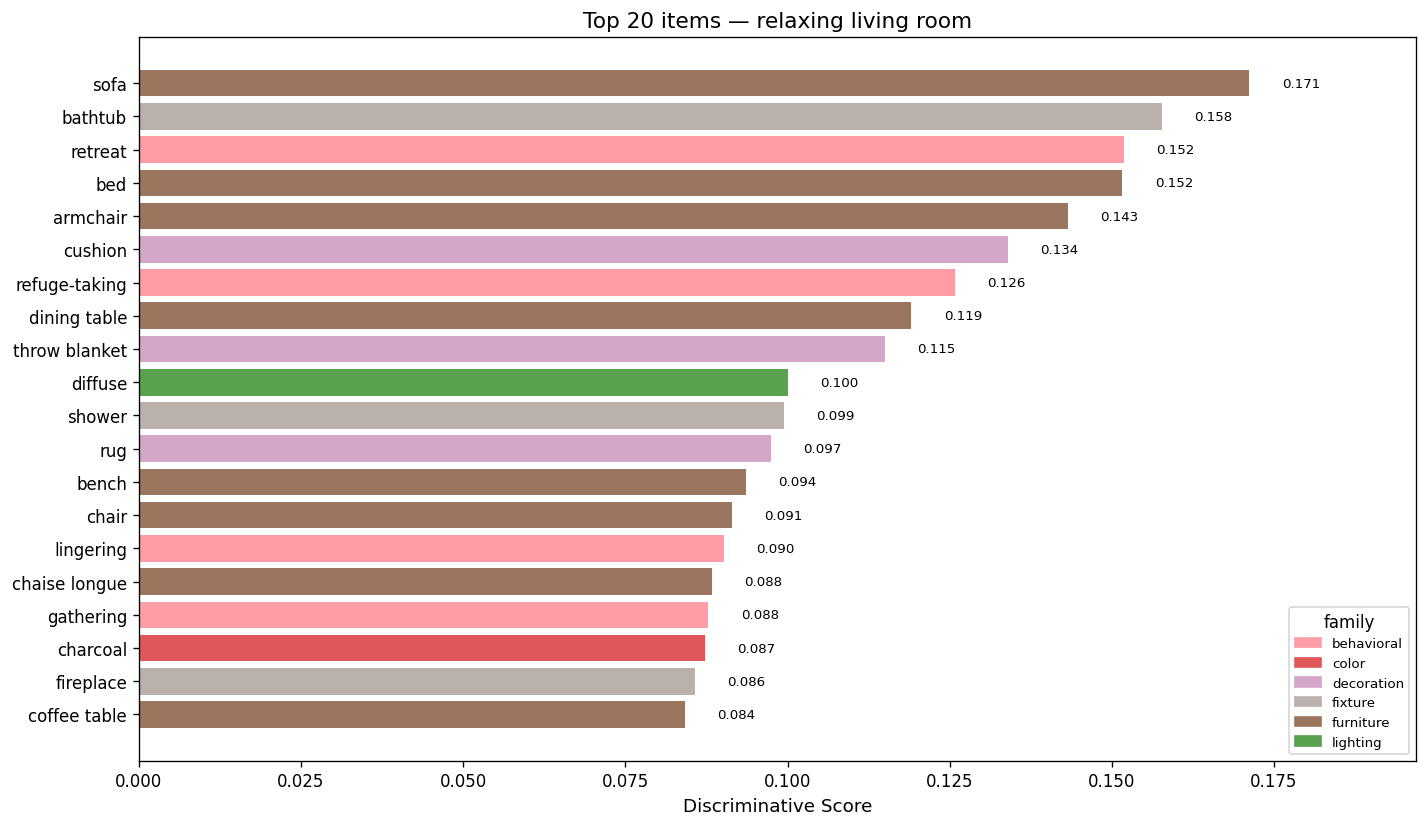

In [53]:
# -- 10a. Bar chart: top atoms for EXPLORE_QUERY --
fig = plot_top_items(
    top_atoms_for_query(explore_qid, atom_scores, k=TOP_K,
                        score_col='discriminative_score'),
    query_label=EXPLORE_QUERY, top_k=TOP_K,
    score_col='discriminative_score', color_by_family=True,
)
safe_q = EXPLORE_QUERY.replace(' ', '_')
fig.savefig(out_dir / f'bar_atoms_{safe_q}.png', bbox_inches='tight', dpi=150)
plt.show()

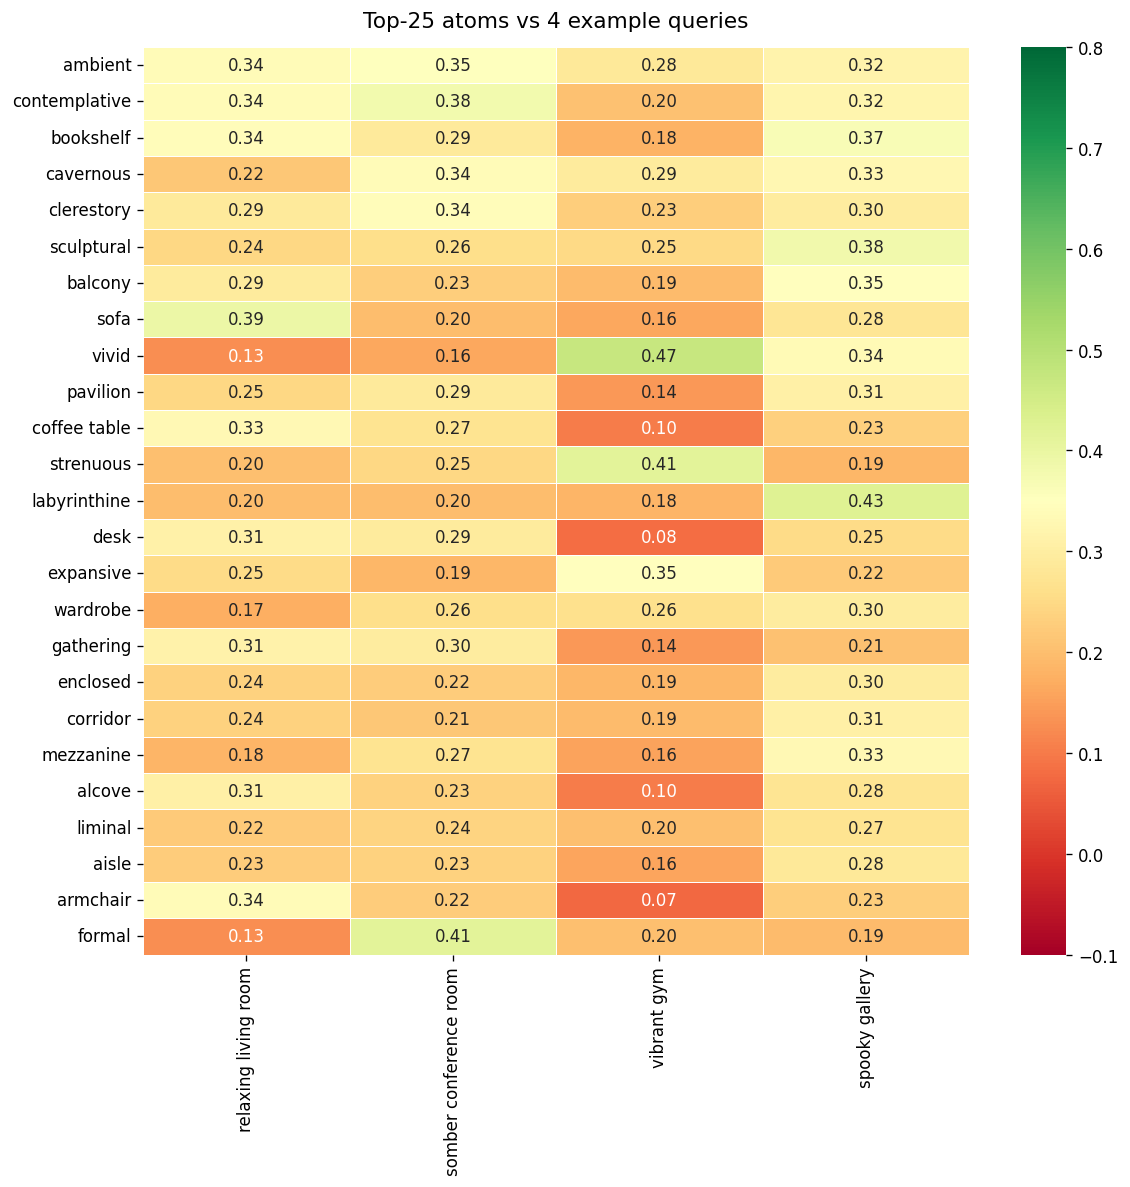

In [54]:
# -- 10b. Heatmap: top-25 atoms x EXAMPLE_QUERIES --
ex_combined_embs, ex_labels = [], []
for qt in EXAMPLE_QUERIES:
    idx = next((i for i, q in enumerate(combined_qs) if q.combined_text == qt), None)
    if idx is not None:
        ex_combined_embs.append(combined_embs[idx])
        ex_labels.append(qt)
ex_combined_embs = np.stack(ex_combined_embs)

ex_qids = list(ex_ids.values())
mean_scores = (
    atom_scores[atom_scores['query_id'].isin(ex_qids)]
    .groupby('text')['weighted_score'].mean()
    .sort_values(ascending=False)
    .head(25)
)
top25_texts = list(mean_scores.index)
top25_idx   = [atom_texts.index(t) for t in top25_texts]
top25_embs  = atom_embs[top25_idx]

mat = similarity_matrix_df(top25_texts, ex_labels, top25_embs, ex_combined_embs)
fig = plot_heatmap(mat, title=f'Top-25 atoms vs {len(ex_labels)} example queries',
                   figsize=(10, 10), annot=True)
fig.savefig(out_dir / 'heatmap_atoms_example_queries.png', bbox_inches='tight', dpi=150)
plt.show()

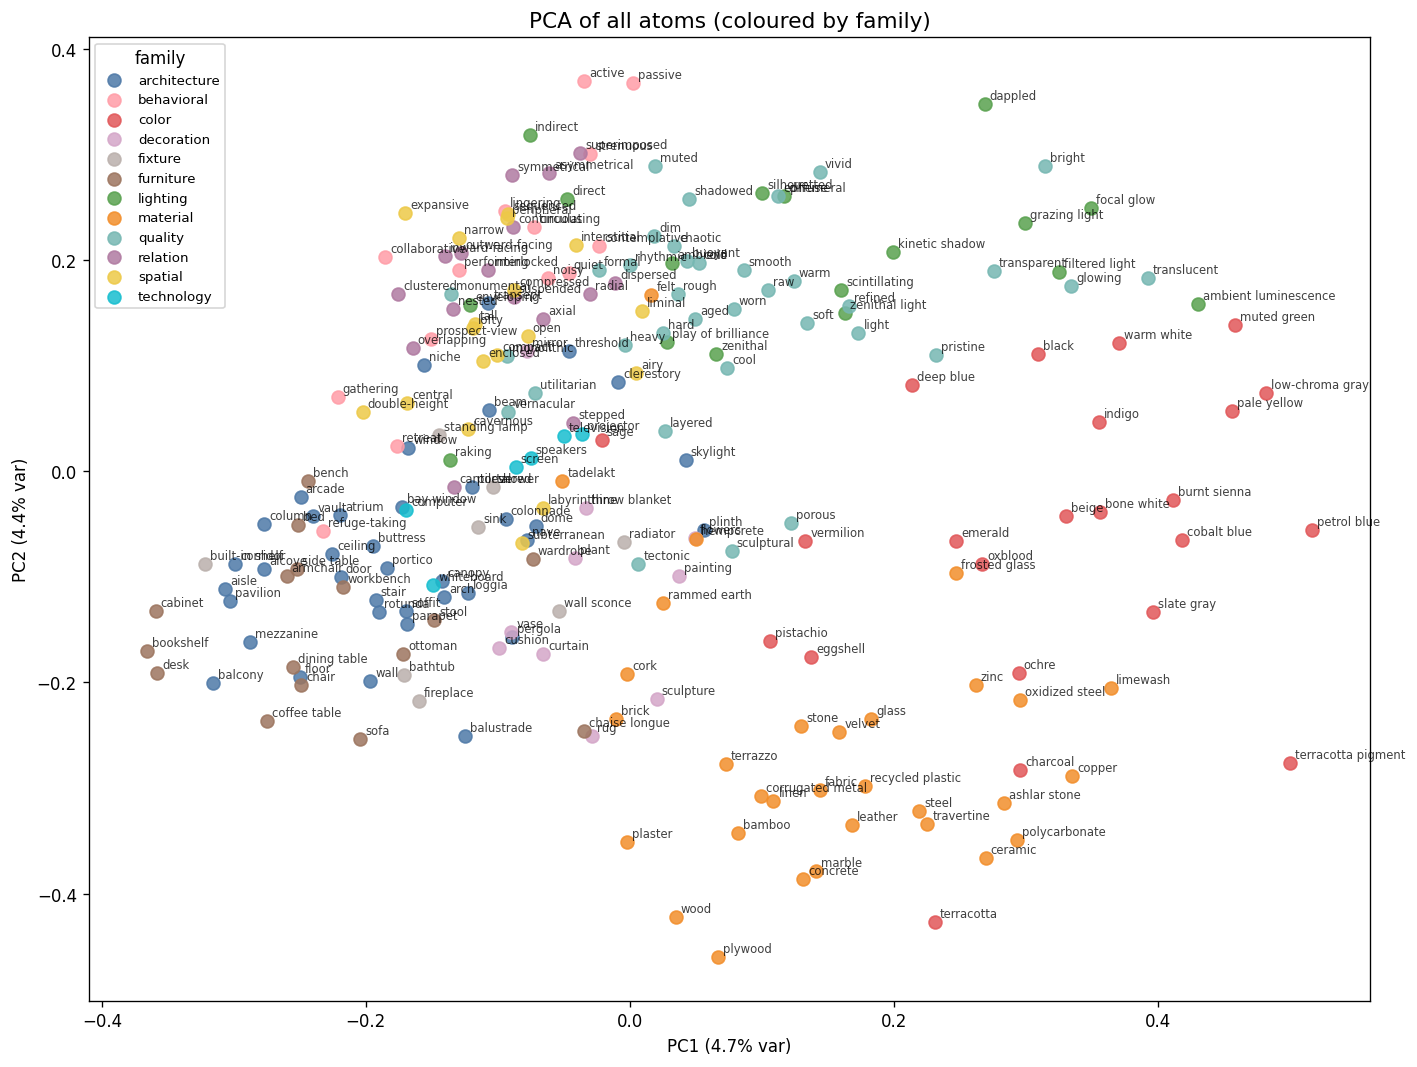

In [55]:
# -- 10c. PCA of all atoms --
fig = plot_pca_projection(
    atom_embs, atom_texts, families=atom_families,
    title='PCA of all atoms (coloured by family)',
    annotate=True, figsize=(12, 9),
)
fig.savefig(out_dir / 'pca_atoms.png', bbox_inches='tight', dpi=150)
plt.show()

C:\Users\Sabin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


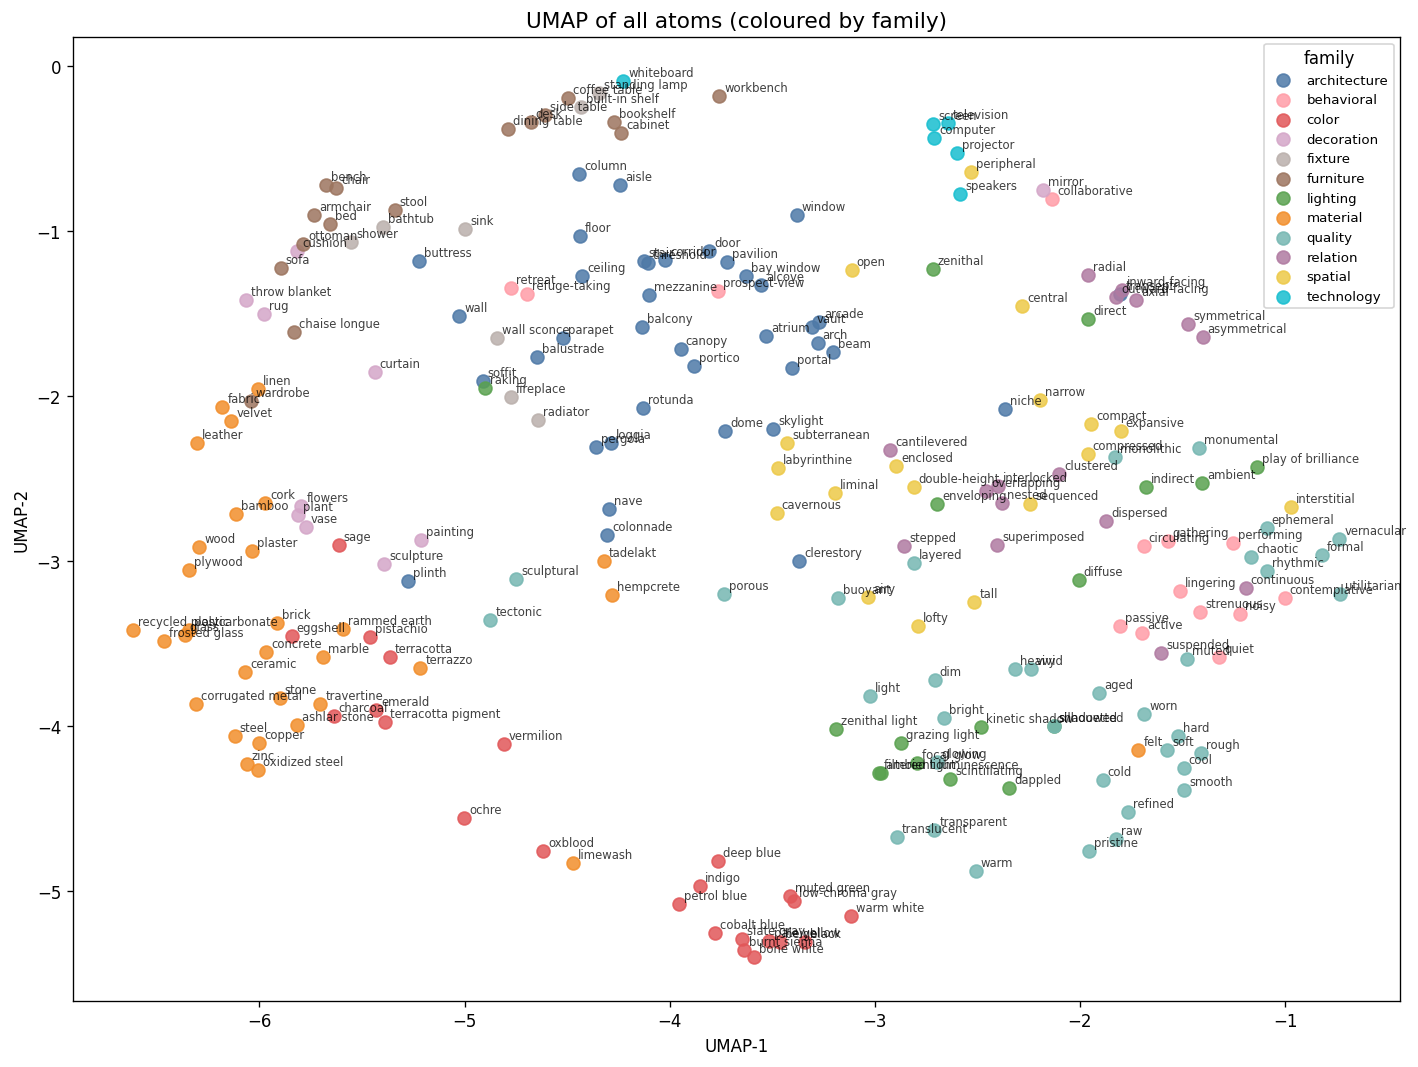

In [56]:
# -- 10d. UMAP (skipped if umap-learn not installed) --
fig = plot_umap_projection(
    atom_embs, atom_texts, families=atom_families,
    title='UMAP of all atoms (coloured by family)',
    annotate=True, figsize=(12, 9),
)
if fig:
    fig.savefig(out_dir / 'umap_atoms.png', bbox_inches='tight', dpi=150)
    plt.show()

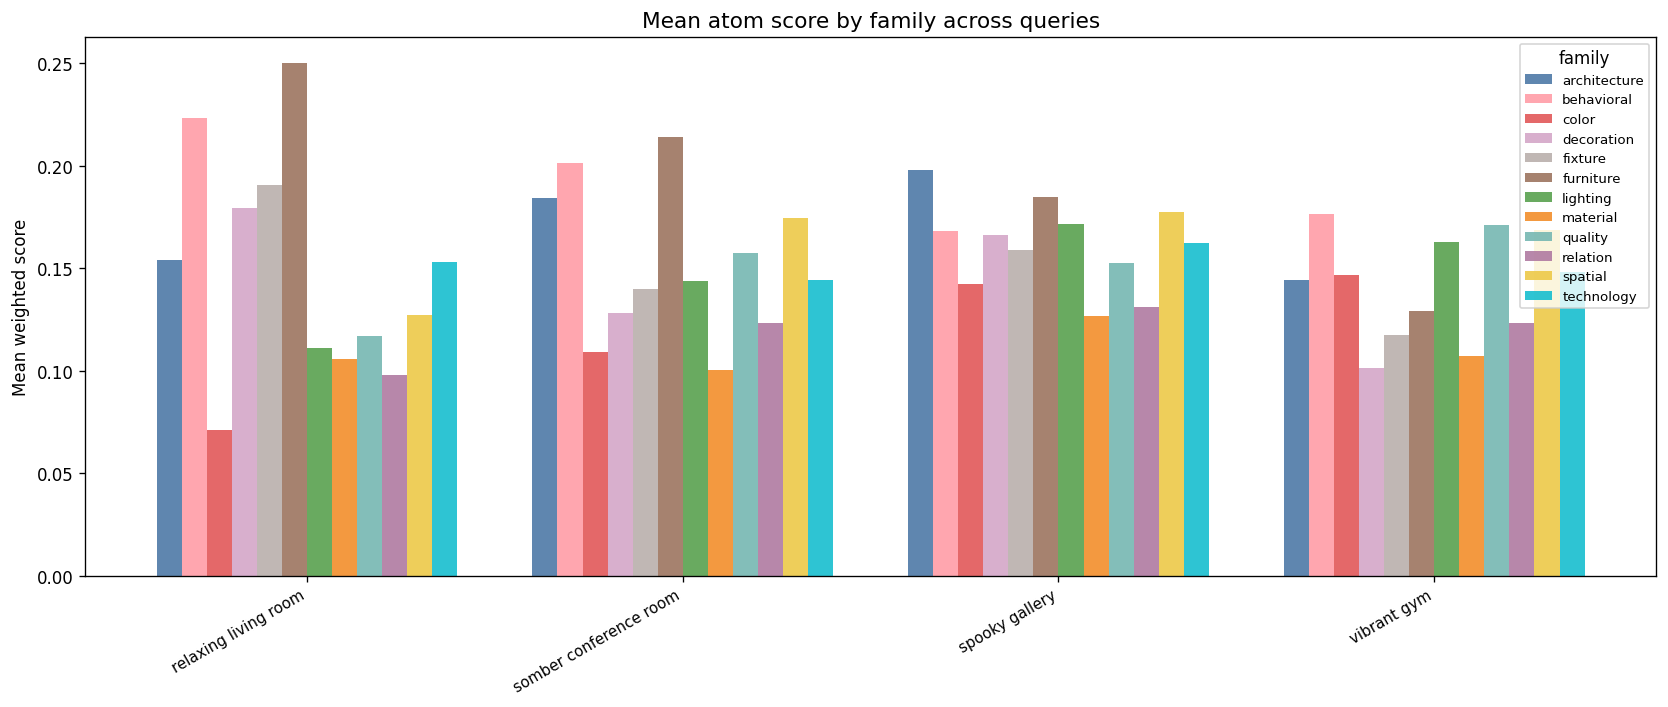

In [57]:
# -- 10e. Family comparison across EXAMPLE_QUERIES --
fig = plot_family_comparison(
    atom_scores, query_ids=ex_qids,
    score_col='weighted_score', figsize=(14, 6),
)
fig.savefig(out_dir / 'family_comparison_example_queries.png', bbox_inches='tight', dpi=150)
plt.show()

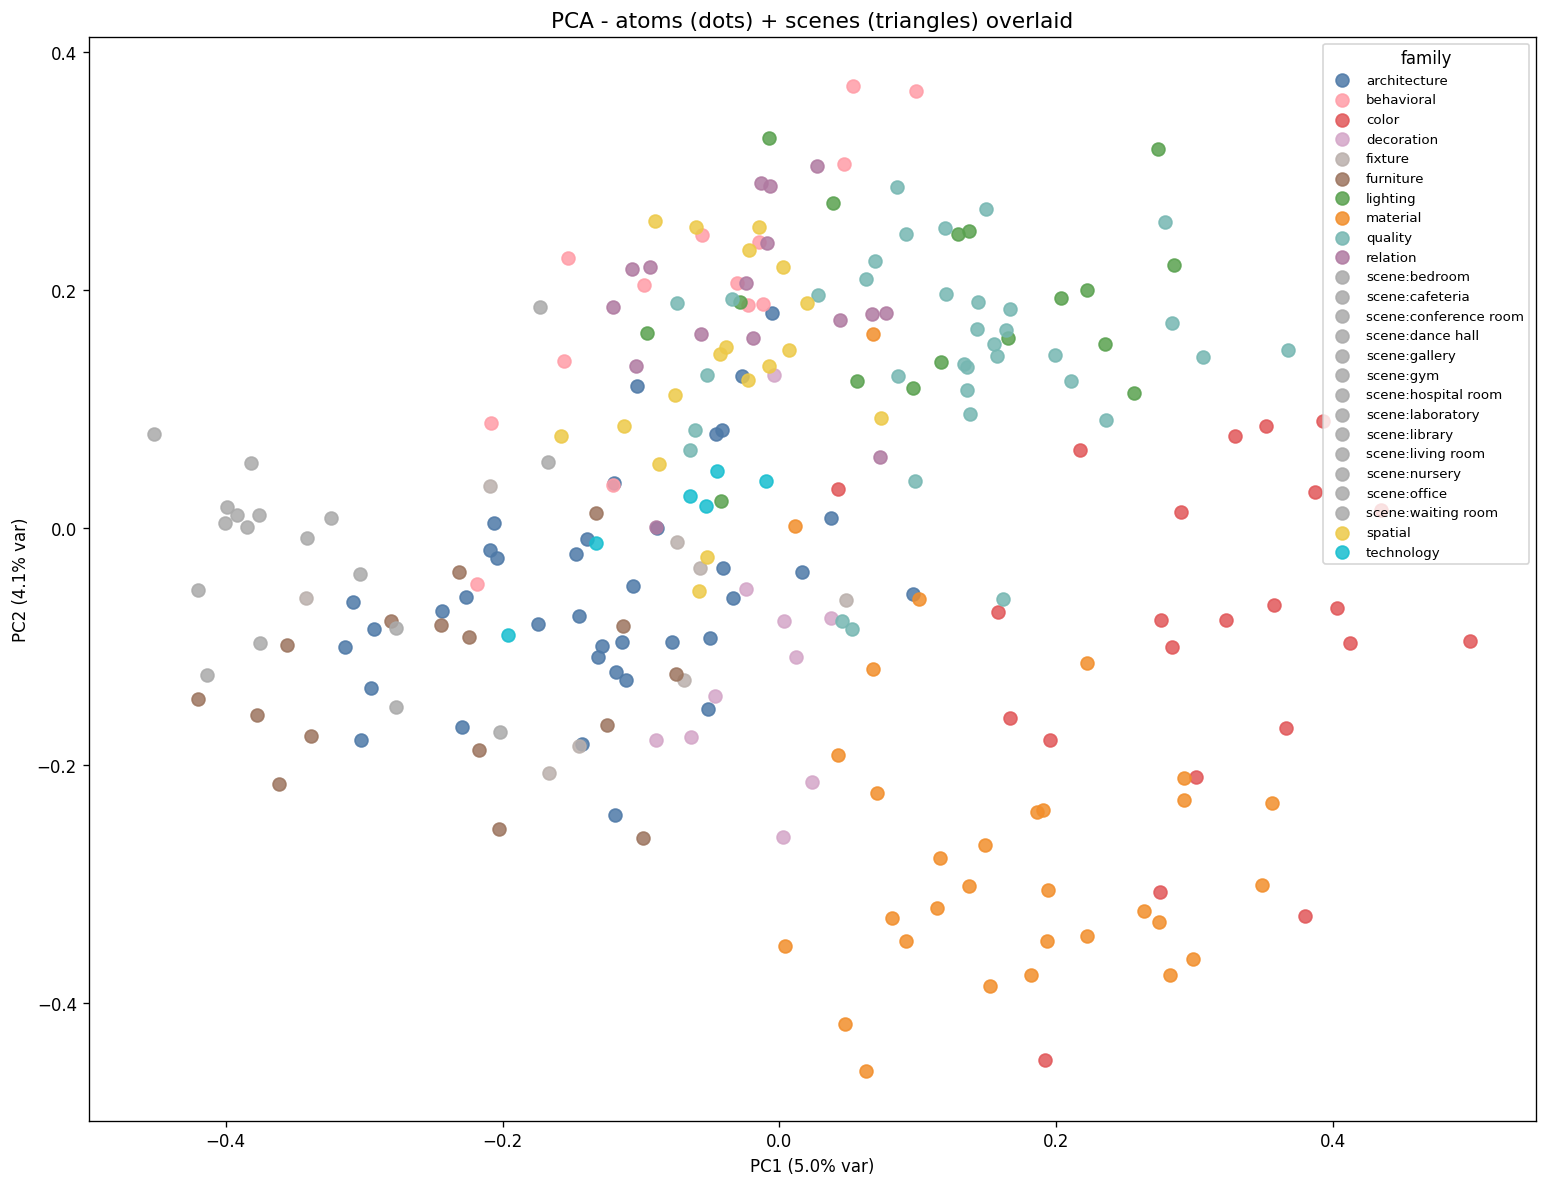

In [58]:
# -- 10f. PCA atoms + scenes overlaid --
all_embs     = np.vstack([atom_embs, scene_embs])
all_texts    = atom_texts + [f'[{s.id}]' for s in scenes]
all_families = atom_families + [f'scene:{s.space}' for s in scenes]

fig = plot_pca_projection(
    all_embs, all_texts, families=all_families,
    title='PCA - atoms (dots) + scenes (triangles) overlaid',
    annotate=False, figsize=(13, 10),
)
fig.savefig(out_dir / 'pca_atoms_scenes.png', bbox_inches='tight', dpi=150)
plt.show()

## Summary

Outputs saved to `data/processed/`:

| File | Contents |
|------|----------|
| `atom_scores.csv` | Atoms x 400 queries |
| `descriptor_scores.csv` | Descriptors x 400 queries |
| `scene_scores.csv` | Scenes x 400 queries |
| `scene_eval.csv` | Hit@1 / Hit@5 ground-truth evaluation |
| `descriptors.csv` | Descriptor list with provenance |
| `ranking_atoms_*.csv` | Per-query atom rankings |
| `ranking_descriptors_*.csv` | Per-query descriptor rankings |
| `ranking_scenes_*.csv` | Per-query scene rankings (NEW) |
| `bar_atoms_*.png` | Bar chart for explore query |
| `heatmap_atoms_example_queries.png` | Heatmap |
| `pca_atoms.png` | PCA projection (atoms only) |
| `pca_atoms_scenes.png` | PCA projection (atoms + scenes) |
| `umap_atoms.png` | UMAP projection |
| `family_comparison_example_queries.png` | Family comparison chart |

> **To explore a different query:** change `EXPLORE_SPACE` and `EXPLORE_AMBIANCE`
> in the Settings cell (section 0b), then re-run sections 3-7.
>
> **To explore a different scene:** change `EXPLORE_SCENE_ID` in the Settings cell.
>
> **To add comparison queries:** add entries to `EXAMPLE_QUERIES` in the Settings cell.